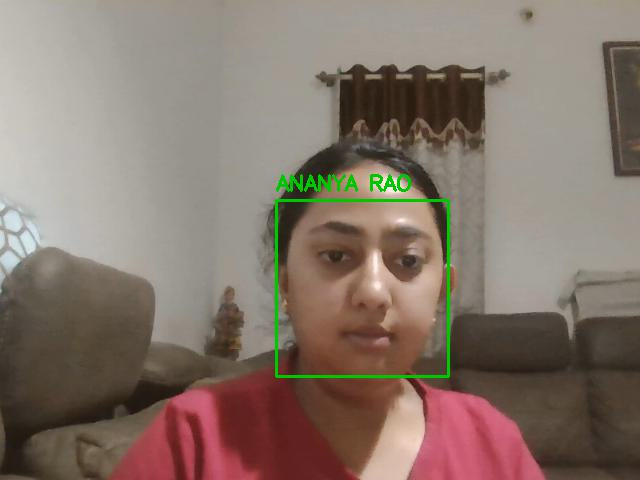

⏹️ Stopped.
📷 Camera released.

📋 Attendance saved to: attendance_2026-04-28.csv


,Name,Time,Date
0,ANANYA RAO,21:07:09,28-04-2026


In [5]:
import face_recognition
import cv2
import pickle
import pandas as pd
from datetime import datetime
import IPython.display
from PIL import Image
import io
from IPython.display import display, clear_output

# Load encodings
with open("encodings.pkl", "rb") as f:
    data = pickle.load(f)

known_encodings = data["encodings"]
known_names     = data["names"]
attendance = {}
asked_faces = {}  # Tracks faces already asked to avoid repeated prompts

def mark_attendance(name):
    if name not in attendance:
        now = datetime.now()
        attendance[name] = {
            "Time": now.strftime("%H:%M:%S"),
            "Date": now.strftime("%d-%m-%Y")
        }
        print(f"✅ Marked: {name} | Time: {now.strftime('%H:%M:%S')} | Date: {now.strftime('%d-%m-%Y')}")

def ask_name_and_save(face_encoding):
    """Ask user for name and save encoding for future recognition."""
    name = input("❓ Unknown face detected! Please enter your full name: ").strip()
    if name:
        known_encodings.append(face_encoding)
        known_names.append(name)
        mark_attendance(name)

        # Save updated encodings permanently
        with open("encodings.pkl", "wb") as f:
            pickle.dump({"encodings": known_encodings, "names": known_names}, f)
        print(f"💾 '{name}' saved! Will be recognized automatically next time.")
    return name

# Start webcam
cap = cv2.VideoCapture(0)
print("🎥 Attendance system running... Press Stop (■) button to quit.")

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        small_frame = cv2.resize(frame, (0, 0), fx=0.25, fy=0.25)
        rgb_small   = cv2.cvtColor(small_frame, cv2.COLOR_BGR2RGB)

        face_locations = face_recognition.face_locations(rgb_small)
        face_encodings = face_recognition.face_encodings(rgb_small, face_locations)

        for face_encoding, face_loc in zip(face_encodings, face_locations):

            name = "Unknown"
            face_distances = face_recognition.face_distance(known_encodings, face_encoding)
            best_match_idx = face_distances.argmin()
            best_distance  = face_distances[best_match_idx]

            if best_distance < 0.36:
                # ✅ Very confident match → recognize directly
                name = known_names[best_match_idx]
                mark_attendance(name)
                color = (0, 200, 0)  # Green

            elif best_distance < 0.55:
                # 🟡 Somewhat confident → recognize but flag as uncertain
                name = f"~{known_names[best_match_idx]}"
                mark_attendance(known_names[best_match_idx])
                color = (0, 165, 255)  # Orange

            else:
                # ❓ Not confident at all → ask for name (only once per new face)
                face_key = tuple(face_encoding[:5].round(2))  # Unique key for this face
                if face_key not in asked_faces:
                    asked_faces[face_key] = True
                    cap.release()  # Pause camera while asking
                    clear_output(wait=True)
                    name = ask_name_and_save(face_encoding)
                    cap = cv2.VideoCapture(0)  # Restart camera after input
                else:
                    name = f"Unknown ({best_distance:.2f})"
                color = (0, 0, 255)  # Red

            top, right, bottom, left = [v * 4 for v in face_loc]
            cv2.rectangle(frame, (left, top), (right, bottom), color, 2)
            cv2.putText(frame, name, (left, top - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

        # Show in Jupyter
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img = Image.fromarray(rgb_frame)
        buf = io.BytesIO()
        img.save(buf, format='JPEG')
        clear_output(wait=True)
        display(IPython.display.Image(data=buf.getvalue()))

except KeyboardInterrupt:
    print("⏹️ Stopped.")

finally:
    cap.release()
    print("📷 Camera released.")

# Save attendance CSV
df = pd.DataFrame([
    {"Name": name, "Time": info["Time"], "Date": info["Date"]}
    for name, info in attendance.items()
])
filename = f"attendance_{datetime.now().strftime('%Y-%m-%d')}.csv"
df.to_csv(filename, index=False)
print(f"\n📋 Attendance saved to: {filename}")
display(df)